In [8]:
# Design of Experiment
demand_status = "D1" # "D1" => "D_low" or "D2" => "D_med" or "D3" => "D_high"
supply_status = "S3" # "S1" => "S_low" or "S2" => "S_med" or "S3" => "S_high"
price_status = "P1" # "P1" => "P_no_discount" 

In [9]:
import torch
import torch.nn as nn
import numpy as np
from torchtext import data
from torchtext import datasets

import json

A = ["Measles", "Mumps", "Rubella", "Diphtheria", "Tetanus", "Pertussis", "Hepatitis_B", "Hib", "IPV", "HPV", "Rotavirus", "PCV"]
V = ["M", "MR", "MMR", "TT", "HepB", "Hib", "IPV", "OPV", "DT", "Td", "DTwP", "DTwP-Hib", "Penta", "Hexa", "HPV", "Rotavirus", "PCV"]

A_v = {
    "M": ["Measles"],
    "MR": ["Measles", "Rubella"],
    "MMR": ["Measles", "Mumps", "Rubella"],
    "TT": ["Tetanus"],
    "HepB": ["Hepatitis_B"],
    "Hib": ["Hib"],
    "IPV": ["IPV"],
    "OPV": ["IPV"],
    "DT": ["Diphtheria", "Tetanus"],
    "Td": ["Diphtheria", "Tetanus"],
    "DTwP": ["Diphtheria", "Tetanus", "Pertussis"],
    "DTwP-Hib": ["Diphtheria", "Tetanus", "Pertussis", "Hib"],
    "Penta": ["Diphtheria", "Tetanus", "Pertussis", "Hepatitis_B", "Hib"],
    "Hexa": ["Diphtheria", "Tetanus", "Pertussis", "Hepatitis_B", "Hib", "IPV"],
    "HPV": ["HPV"],
    "Rotavirus": ["Rotavirus"],
    "PCV": ["PCV"]
}

V_a = {}
for a in A:
    vector_a = []
    for v in A_v.keys():
        if a in A_v[v]:
            vector_a.append(v)
    V_a[a] = vector_a

P = ["AJ_Vaccines","BB_NCIPD","Beijing_Institute","Bharat_Biotech","Bilthoven","Biological_E","Centro_de","GSK","Haffkine_Bio",
        "LG_Chem","Merck_Sharp","Panacea_Biotec","PT_Bio","Sanofi_Pasteur","Serum_Institute","Xiamen_Innovax","Pfizer"]
P_v = {
    "M": ["Serum_Institute", "PT_Bio"],
    "MR": ["Serum_Institute", "Biological_E"],
    "MMR": ["Serum_Institute", "GSK", "Merck_Sharp"],
    "TT": ["Serum_Institute", "PT_Bio", "BB_NCIPD"],
    "HepB": ["Serum_Institute", "LG_Chem"],
    "Hib": ["Serum_Institute", "Sanofi_Pasteur", "Centro_de"],
    "IPV": ["LG_Chem", "AJ_Vaccines", "Bilthoven", "Sanofi_Pasteur"],
    "OPV": ["Serum_Institute", "PT_Bio", "GSK", "Sanofi_Pasteur", "Panacea_Biotec", "Beijing_Institute", "Bharat_Biotech", "Haffkine_Bio"],
    "DT": ["Serum_Institute", "PT_Bio", "BB_NCIPD"],
    "Td": ["Serum_Institute", "PT_Bio", "BB_NCIPD"],
    "DTwP": ["Serum_Institute", "Biological_E"],
    "DTwP-Hib": ["Serum_Institute"],
    "Penta": ["Serum_Institute", "PT_Bio", "Biological_E", "LG_Chem", "Panacea_Biotec"],
    "Hexa": ["Sanofi_Pasteur"],
    "HPV": ["GSK", "Merck_Sharp", "Xiamen_Innovax"],
    "Rotavirus": ["Serum_Institute", "GSK", "Bharat_Biotech"],
    "PCV": ["Serum_Institute", "GSK", "Pfizer"]
}


V_p = {}
for p in P:
    vector_p = []
    for v in P_v.keys():
        if p in P_v[v]:
            vector_p.append(v)
    V_p[p] = vector_p

tmin = 1
tmax = 10
T = [t for t in range(tmin, tmax + 1)]
T_initial = [t for t in range(tmin - 1, tmax)]

Δ = [1,3,5]

In [23]:
producer_color_map = {
    "Serum_Institute": "blue",
    "PT_Bio": "green",
    "Biological_E": "red",
    "LG_Chem": "purple",
    "Sanofi_Pasteur": "orange",
    "Centro_de": "cyan",
    "AJ_Vaccines": "magenta",
    "Bilthoven": "yellow",
    "GSK": "brown",
    "Haffkine_Bio": "pink",
    "Merck_Sharp": "gray",
    "Panacea_Biotec": "olive",
    "Beijing_Institute": "teal",
    "Bharat_Biotech": "navy",
    "Xiamen_Innovax": "lime",
    "Pfizer": "indigo",
    "BB_NCIPD": "gold"
    # Add more producers and their corresponding colors as needed
}

vaccine_color_map = {
-    "M": "blue",
    "MR": "green",
    "MMR": "red",
    "TT": "purple",
    "HepB": "orange",
    "Hib": "cyan",
    "IPV": "magenta",
    "OPV": "yellow",
    "DT": "brown",
    "Td": "pink",
    "DTwP": "gray",
    "DTwP-Hib": "olive",
    "Penta": "teal",
    "Hexa": "navy",
    "HPV": "lime",
    "Rotavirus": "indigo",
    "PCV": "gold"
    # Add more vaccines and their corresponding colors as needed
}

{'PCV': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'Measles': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'IPV': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'Mumps': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'HPV': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'Hib': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'Pertussis': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'Rotavirus': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'Diphtheria': {'5': {}, '4': {}, '6': {'10': 

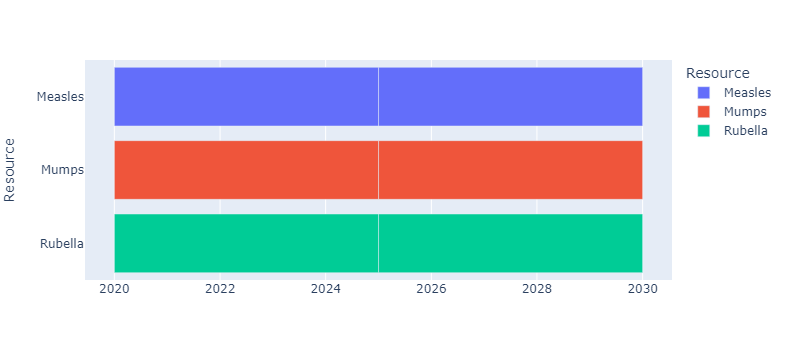

In [10]:
import plotly.express as px
import pandas as pd

with open('C:/Users/fthcn/Desktop/Vaccine_Tender_Scheduling_Problem/Julia_Files/Github/Results/F_results_'+demand_status+'_'+supply_status+'_'+price_status+'.json') as json_file:
    F_results = json.load(json_file)

print(F_results)

group = ["Measles","Mumps","Rubella"]

output = pd.DataFrame()
for a in group:
    if a in F_results:
        for t in T:
            if len(F_results[a][str(t)]) != 0:
                end_list = list(F_results[a][str(t)])
                end_time = int(end_list[0])
                df_dictionary = pd.DataFrame([dict(Start=str(2020+t-1), Finish=str(2020+end_time), Resource=a)])
                output = pd.concat([output, df_dictionary], ignore_index=True)

fig = px.timeline(output, x_start="Start", x_end="Finish", y="Resource", color="Resource")
fig.show()

{'PCV': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'Measles': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'IPV': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'Mumps': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'HPV': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'Hib': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'Pertussis': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'Rotavirus': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'Diphtheria': {'5': {}, '4': {}, '6': {'10': 

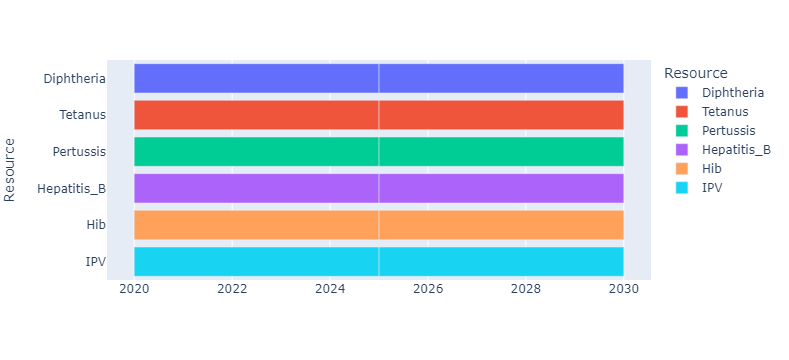

In [11]:
import plotly.express as px
import pandas as pd

with open('C:/Users/fthcn/Desktop/Vaccine_Tender_Scheduling_Problem/Julia_Files/Github/Results/F_results_'+demand_status+'_'+supply_status+'_'+price_status+'.json') as json_file:
    F_results = json.load(json_file)

print(F_results)

group = ["Diphtheria","Tetanus","Pertussis","Hepatitis_B","Hib","IPV"]

output = pd.DataFrame()
for a in group:
    if a in F_results:
        for t in T:
            if len(F_results[a][str(t)]) != 0:
                end_list = list(F_results[a][str(t)])
                end_time = int(end_list[0])
                df_dictionary = pd.DataFrame([dict(Start=str(2020+t-1), Finish=str(2020+end_time), Resource=a)])
                output = pd.concat([output, df_dictionary], ignore_index=True)

fig = px.timeline(output, x_start="Start", x_end="Finish", y="Resource", color="Resource")
fig.show()

{'PCV': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'Measles': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'IPV': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'Mumps': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'HPV': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'Hib': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'Pertussis': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'Rotavirus': {'5': {}, '4': {}, '6': {'10': 1.0}, '7': {}, '2': {}, '10': {}, '9': {}, '8': {}, '3': {}, '1': {'5': 1.0}}, 'Diphtheria': {'5': {}, '4': {}, '6': {'10': 

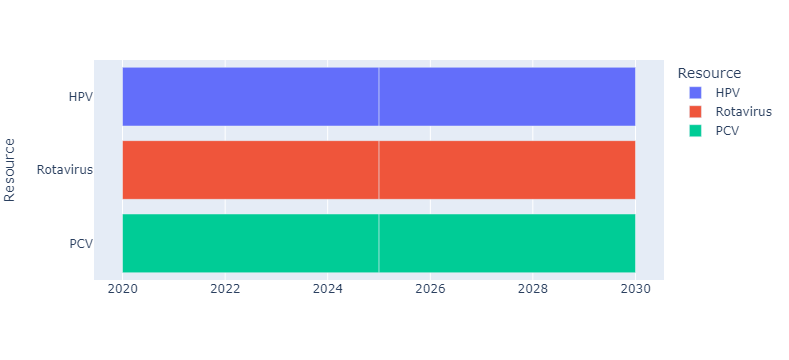

In [12]:
import plotly.express as px
import pandas as pd

with open('C:/Users/fthcn/Desktop/Vaccine_Tender_Scheduling_Problem/Julia_Files/Github/Results/F_results_'+demand_status+'_'+supply_status+'_'+price_status+'.json') as json_file:
    F_results = json.load(json_file)

print(F_results)

group = ["HPV", "Rotavirus", "PCV"]

output = pd.DataFrame()
for a in group:
    if a in F_results:
        for t in T:
            if len(F_results[a][str(t)]) != 0:
                end_list = list(F_results[a][str(t)])
                end_time = int(end_list[0])
                df_dictionary = pd.DataFrame([dict(Start=str(2020+t-1), Finish=str(2020+end_time), Resource=a)])
                output = pd.concat([output, df_dictionary], ignore_index=True)

fig = px.timeline(output, x_start="Start", x_end="Finish", y="Resource", color="Resource")
fig.show()

{'PCV': {'Serum_Institute': {'5': 176800000.0, '4': 164720000.0, '6': 175280000.0, '7': 161176007.717374, '2': 149600000.0, '10': 176160000.0, '9': 175040000.0, '8': 159272175.92003447, '3': 165666573.79537922, '1': 103581955.75085305}, 'Pfizer': {}, 'GSK': {'7': 16663992.282626003, '8': 14567824.079965517, '3': 1693426.2046207925, '1': 25058044.24914695}}, 'DTwP-Hib': {'Serum_Institute': {'5': 218352952.83018866, '4': 218117962.26415095, '6': 216000000.0, '7': 218480000.0, '2': 226240000.0, '10': 221360000.0, '9': 218960000.0, '8': 216320000.0, '3': 229840000.0, '1': 207600000.0}}, 'IPV': {'LG_Chem': {}, 'Sanofi_Pasteur': {}, 'Bilthoven': {}, 'AJ_Vaccines': {}}, 'Hexa': {'Sanofi_Pasteur': {}}, 'HPV': {'Merck_Sharp': {'5': 18240000.0, '4': 14280000.0, '6': 8337658.357875951, '2': 3720000.0, '9': 6600000.0}, 'GSK': {'5': 52920000.0, '4': 41560000.0, '6': 41262341.64212405, '7': 32320000.0, '8': 32480000.0, '3': 31880000.0, '1': 14600000.0}, 'Xiamen_Innovax': {'5': 3000000.0, '4': 240000

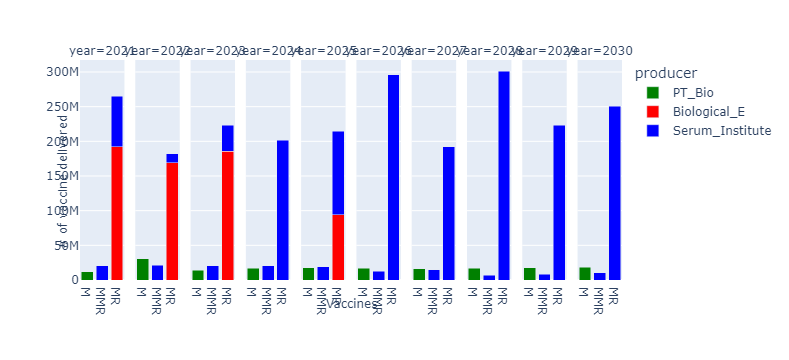

In [20]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go

with open('C:/Users/fthcn/Desktop/Vaccine_Tender_Scheduling_Problem/Julia_Files/Github/Results/X_results_'+demand_status+'_'+supply_status+'_'+price_status+'.json') as json_file:
    X_results = json.load(json_file)

print(X_results)


# P = ["AJ_Vaccines","BB_NCIPD","Beijing_Institute","Bharat_Biotech","Bilthoven","Biological_E","Centro_de","GSK","Haffkine_Bio",
#         "LG_Chem","Merck_Sharp","Panacea_Biotec","PT_Bio","Sanofi_Pasteur","Serum_Institute","Xiamen_Innovax","Pfizer"]

group = ["M","MR","MMR"]

output = pd.DataFrame()
for v in group:
    if v in X_results:
        #print(v)
        for p in P_v[v]:
            #print(p)
            for t in T:
                if str(t) in X_results[v][p]:
                    if X_results[v][p][str(t)] >= 1:
                        X_results[v][p][str(t)] = round(X_results[v][p][str(t)])
                        df_dictionary = pd.DataFrame([dict(year=str(2020+t), var=X_results[v][p][str(t)], vaccine=v, producer=p)])
                        output = pd.concat([output, df_dictionary], ignore_index=True)
output.sort_values(['year'],ascending=[True],inplace=True)
# fig = px.bar(output, x="vaccine", y="var", facet_col="year", color="producer")

fig = px.bar(output, x="vaccine", y="var", facet_col="year", color="producer",
             color_discrete_map=producer_color_map)

fig.for_each_xaxis(lambda x: x.update(title = ''))
fig.for_each_yaxis(lambda y: y.update(title = ''))
# and:
fig.add_annotation(x=-0.05,y=0.45, showarrow=False,
                   text="# of vaccine delivered", textangle=-90,
                    xref="paper", yref="paper")
fig.add_annotation(x=0.5,y=-0.15, showarrow=False,
                   text="Vaccines", textangle=0,
                    xref="paper", yref="paper")
fig.update_layout(barmode='stack', xaxis={'categoryorder':'category ascending'})
fig.show()

{'PCV': {'Serum_Institute': {'5': 176800000.0, '4': 164720000.0, '6': 175280000.0, '7': 161176007.717374, '2': 149600000.0, '10': 176160000.0, '9': 175040000.0, '8': 159272175.92003447, '3': 165666573.79537922, '1': 103581955.75085305}, 'Pfizer': {}, 'GSK': {'7': 16663992.282626003, '8': 14567824.079965517, '3': 1693426.2046207925, '1': 25058044.24914695}}, 'DTwP-Hib': {'Serum_Institute': {'5': 218352952.83018866, '4': 218117962.26415095, '6': 216000000.0, '7': 218480000.0, '2': 226240000.0, '10': 221360000.0, '9': 218960000.0, '8': 216320000.0, '3': 229840000.0, '1': 207600000.0}}, 'IPV': {'LG_Chem': {}, 'Sanofi_Pasteur': {}, 'Bilthoven': {}, 'AJ_Vaccines': {}}, 'Hexa': {'Sanofi_Pasteur': {}}, 'HPV': {'Merck_Sharp': {'5': 18240000.0, '4': 14280000.0, '6': 8337658.357875951, '2': 3720000.0, '9': 6600000.0}, 'GSK': {'5': 52920000.0, '4': 41560000.0, '6': 41262341.64212405, '7': 32320000.0, '8': 32480000.0, '3': 31880000.0, '1': 14600000.0}, 'Xiamen_Innovax': {'5': 3000000.0, '4': 240000

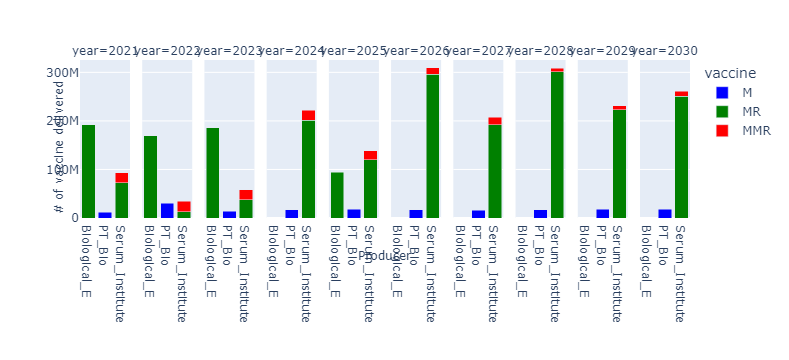

In [24]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go

with open('C:/Users/fthcn/Desktop/Vaccine_Tender_Scheduling_Problem/Julia_Files/Github/Results/X_results_'+demand_status+'_'+supply_status+'_'+price_status+'.json') as json_file:
    X_results = json.load(json_file)

print(X_results)

group = ["M","MR","MMR"]

output = pd.DataFrame()
for v in group:
    if v in X_results:
        #print(v)
        for p in P_v[v]:
            #print(p)
            for t in T:
                if str(t) in X_results[v][p]:
                    if X_results[v][p][str(t)] >= 1:
                        X_results[v][p][str(t)] = round(X_results[v][p][str(t)])
                        df_dictionary = pd.DataFrame([dict(year=str(2020+t), var=X_results[v][p][str(t)], vaccine=v, producer=p)])
                        output = pd.concat([output, df_dictionary], ignore_index=True)
output.sort_values(['year'],ascending=[True],inplace=True)
fig = px.bar(output, x="producer", y="var", facet_col="year", color="vaccine", color_discrete_map=vaccine_color_map)

fig.for_each_xaxis(lambda x: x.update(title = ''))
fig.for_each_yaxis(lambda y: y.update(title = ''))
# and:
fig.add_annotation(x=-0.05,y=0.45, showarrow=False,
                   text="# of vaccine delivered", textangle=-90,
                    xref="paper", yref="paper")
fig.add_annotation(x=0.5,y=-0.30, showarrow=False,
                   text="Producer", textangle=0,
                    xref="paper", yref="paper")
fig.update_layout(barmode='stack', xaxis={'categoryorder':'category ascending'})
fig.show()

{'PCV': {'Serum_Institute': {'5': 176800000.0, '4': 164720000.0, '6': 175280000.0, '7': 161176007.717374, '2': 149600000.0, '10': 176160000.0, '9': 175040000.0, '8': 159272175.92003447, '3': 165666573.79537922, '1': 103581955.75085305}, 'Pfizer': {}, 'GSK': {'7': 16663992.282626003, '8': 14567824.079965517, '3': 1693426.2046207925, '1': 25058044.24914695}}, 'DTwP-Hib': {'Serum_Institute': {'5': 218352952.83018866, '4': 218117962.26415095, '6': 216000000.0, '7': 218480000.0, '2': 226240000.0, '10': 221360000.0, '9': 218960000.0, '8': 216320000.0, '3': 229840000.0, '1': 207600000.0}}, 'IPV': {'LG_Chem': {}, 'Sanofi_Pasteur': {}, 'Bilthoven': {}, 'AJ_Vaccines': {}}, 'Hexa': {'Sanofi_Pasteur': {}}, 'HPV': {'Merck_Sharp': {'5': 18240000.0, '4': 14280000.0, '6': 8337658.357875951, '2': 3720000.0, '9': 6600000.0}, 'GSK': {'5': 52920000.0, '4': 41560000.0, '6': 41262341.64212405, '7': 32320000.0, '8': 32480000.0, '3': 31880000.0, '1': 14600000.0}, 'Xiamen_Innovax': {'5': 3000000.0, '4': 240000

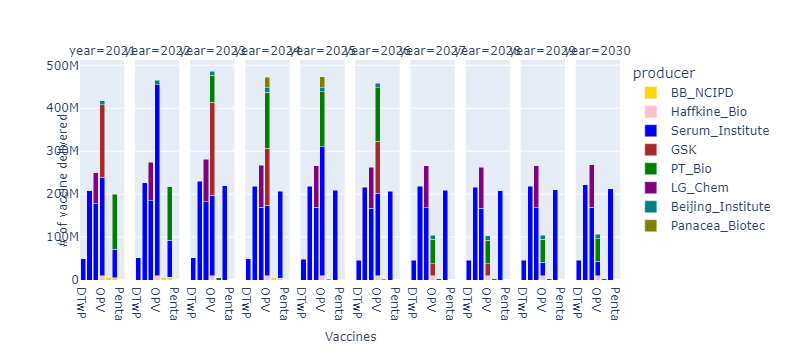

In [21]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go

with open('C:/Users/fthcn/Desktop/Vaccine_Tender_Scheduling_Problem/Julia_Files/Github/Results/X_results_'+demand_status+'_'+supply_status+'_'+price_status+'.json') as json_file:
    X_results = json.load(json_file)

print(X_results)

group = ["TT", "HepB", "Hib", "IPV", "OPV", "DT", "Td", "DTwP", "DTwP-Hib", "Penta", "Hexa"]

output = pd.DataFrame()
for v in group:
    if v in X_results:
        #print(v)
        for p in P_v[v]:
            #print(p)
            for t in T:
                if str(t) in X_results[v][p]:
                    if X_results[v][p][str(t)] >= 1:
                        X_results[v][p][str(t)] = round(X_results[v][p][str(t)])
                        df_dictionary = pd.DataFrame([dict(year=str(2020+t), var=X_results[v][p][str(t)], vaccine=v, producer=p)])
                        output = pd.concat([output, df_dictionary], ignore_index=True)
output.sort_values(['vaccine'],ascending=[False],inplace=True)
output.sort_values(['year'],ascending=[True],inplace=True)
fig = px.bar(output, x="vaccine", y="var", facet_col="year", color="producer",
             color_discrete_map=producer_color_map)

fig.for_each_xaxis(lambda x: x.update(title = ''))
fig.for_each_yaxis(lambda y: y.update(title = ''))
# and:
fig.add_annotation(x=-0.05,y=0.45, showarrow=False,
                   text="# of vaccine delivered", textangle=-90,
                    xref="paper", yref="paper")
fig.add_annotation(x=0.5,y=-0.30, showarrow=False,
                   text="Vaccines", textangle=0,
                    xref="paper", yref="paper")
fig.update_layout(barmode='stack', xaxis={'categoryorder':'category ascending'})
fig.show()

{'PCV': {'Serum_Institute': {'5': 176800000.0, '4': 164720000.0, '6': 175280000.0, '7': 161176007.717374, '2': 149600000.0, '10': 176160000.0, '9': 175040000.0, '8': 159272175.92003447, '3': 165666573.79537922, '1': 103581955.75085305}, 'Pfizer': {}, 'GSK': {'7': 16663992.282626003, '8': 14567824.079965517, '3': 1693426.2046207925, '1': 25058044.24914695}}, 'DTwP-Hib': {'Serum_Institute': {'5': 218352952.83018866, '4': 218117962.26415095, '6': 216000000.0, '7': 218480000.0, '2': 226240000.0, '10': 221360000.0, '9': 218960000.0, '8': 216320000.0, '3': 229840000.0, '1': 207600000.0}}, 'IPV': {'LG_Chem': {}, 'Sanofi_Pasteur': {}, 'Bilthoven': {}, 'AJ_Vaccines': {}}, 'Hexa': {'Sanofi_Pasteur': {}}, 'HPV': {'Merck_Sharp': {'5': 18240000.0, '4': 14280000.0, '6': 8337658.357875951, '2': 3720000.0, '9': 6600000.0}, 'GSK': {'5': 52920000.0, '4': 41560000.0, '6': 41262341.64212405, '7': 32320000.0, '8': 32480000.0, '3': 31880000.0, '1': 14600000.0}, 'Xiamen_Innovax': {'5': 3000000.0, '4': 240000

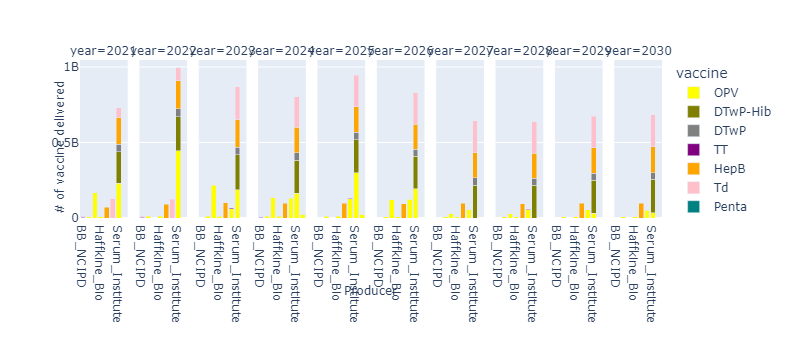

In [25]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go

with open('C:/Users/fthcn/Desktop/Vaccine_Tender_Scheduling_Problem/Julia_Files/Github/Results/X_results_'+demand_status+'_'+supply_status+'_'+price_status+'.json') as json_file:
    X_results = json.load(json_file)

print(X_results)

group = ["TT", "HepB", "Hib", "IPV", "OPV", "DT", "Td", "DTwP", "DTwP-Hib", "Penta", "Hexa"]

output = pd.DataFrame()
for v in group:
    if v in X_results:
        #print(v)
        for p in P_v[v]:
            #print(p)
            for t in T:
                if str(t) in X_results[v][p]:
                    if X_results[v][p][str(t)] >= 1:
                        X_results[v][p][str(t)] = round(X_results[v][p][str(t)])
                        df_dictionary = pd.DataFrame([dict(year=str(2020+t), var=X_results[v][p][str(t)], vaccine=v, producer=p)])
                        output = pd.concat([output, df_dictionary], ignore_index=True)
output.sort_values(['year'],ascending=[True],inplace=True)
fig = px.bar(output, x="producer", y="var", facet_col="year", color="vaccine", color_discrete_map=vaccine_color_map)

fig.for_each_xaxis(lambda x: x.update(title = ''))
fig.for_each_yaxis(lambda y: y.update(title = ''))
# and:
fig.add_annotation(x=-0.05,y=0.45, showarrow=False,
                   text="# of vaccine delivered", textangle=-90,
                    xref="paper", yref="paper")
fig.add_annotation(x=0.5,y=-0.52, showarrow=False,
                   text="Producer", textangle=0,
                    xref="paper", yref="paper")
fig.update_layout(barmode='stack', xaxis={'categoryorder':'category ascending'})
fig.show()

{'PCV': {'Serum_Institute': {'5': 176800000.0, '4': 164720000.0, '6': 175280000.0, '7': 161176007.717374, '2': 149600000.0, '10': 176160000.0, '9': 175040000.0, '8': 159272175.92003447, '3': 165666573.79537922, '1': 103581955.75085305}, 'Pfizer': {}, 'GSK': {'7': 16663992.282626003, '8': 14567824.079965517, '3': 1693426.2046207925, '1': 25058044.24914695}}, 'DTwP-Hib': {'Serum_Institute': {'5': 218352952.83018866, '4': 218117962.26415095, '6': 216000000.0, '7': 218480000.0, '2': 226240000.0, '10': 221360000.0, '9': 218960000.0, '8': 216320000.0, '3': 229840000.0, '1': 207600000.0}}, 'IPV': {'LG_Chem': {}, 'Sanofi_Pasteur': {}, 'Bilthoven': {}, 'AJ_Vaccines': {}}, 'Hexa': {'Sanofi_Pasteur': {}}, 'HPV': {'Merck_Sharp': {'5': 18240000.0, '4': 14280000.0, '6': 8337658.357875951, '2': 3720000.0, '9': 6600000.0}, 'GSK': {'5': 52920000.0, '4': 41560000.0, '6': 41262341.64212405, '7': 32320000.0, '8': 32480000.0, '3': 31880000.0, '1': 14600000.0}, 'Xiamen_Innovax': {'5': 3000000.0, '4': 240000

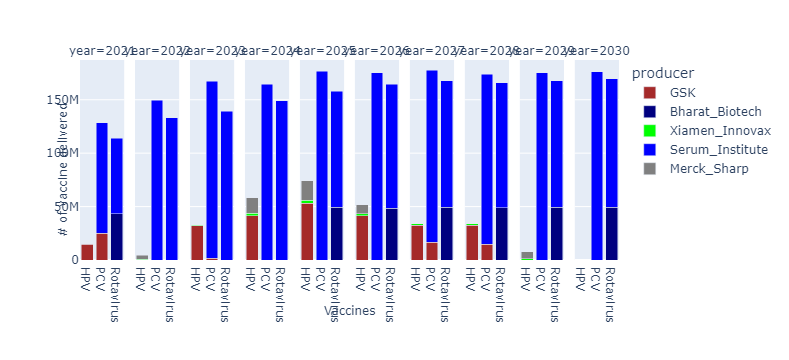

In [28]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go

with open('C:/Users/fthcn/Desktop/Vaccine_Tender_Scheduling_Problem/Julia_Files/Github/Results/X_results_'+demand_status+'_'+supply_status+'_'+price_status+'.json') as json_file:
    X_results = json.load(json_file)

print(X_results)

group = ["HPV", "Rotavirus", "PCV"]

output = pd.DataFrame()
for v in group:
    if v in X_results:
        #print(v)
        for p in P_v[v]:
            #print(p)
            for t in T:
                if str(t) in X_results[v][p]:
                    if X_results[v][p][str(t)] >= 1:
                        X_results[v][p][str(t)] = round(X_results[v][p][str(t)])
                        df_dictionary = pd.DataFrame([dict(year=str(2020+t), var=X_results[v][p][str(t)], vaccine=v, producer=p)])
                        output = pd.concat([output, df_dictionary], ignore_index=True)
output.sort_values(['year'],ascending=[True],inplace=True)
fig = px.bar(output, x="vaccine", y="var", facet_col="year", color="producer",
             color_discrete_map=producer_color_map)

fig.for_each_xaxis(lambda x: x.update(title = ''))
fig.for_each_yaxis(lambda y: y.update(title = ''))
# and:
fig.add_annotation(x=-0.05,y=0.45, showarrow=False,
                   text="# of vaccine delivered", textangle=-90,
                    xref="paper", yref="paper")
fig.add_annotation(x=0.5,y=-0.30, showarrow=False,
                   text="Vaccines", textangle=0,
                    xref="paper", yref="paper")
fig.update_layout(barmode='stack', xaxis={'categoryorder':'category ascending'})
fig.show()

{'PCV': {'Serum_Institute': {'5': 176800000.0, '4': 164720000.0, '6': 175280000.0, '7': 161176007.717374, '2': 149600000.0, '10': 176160000.0, '9': 175040000.0, '8': 159272175.92003447, '3': 165666573.79537922, '1': 103581955.75085305}, 'Pfizer': {}, 'GSK': {'7': 16663992.282626003, '8': 14567824.079965517, '3': 1693426.2046207925, '1': 25058044.24914695}}, 'DTwP-Hib': {'Serum_Institute': {'5': 218352952.83018866, '4': 218117962.26415095, '6': 216000000.0, '7': 218480000.0, '2': 226240000.0, '10': 221360000.0, '9': 218960000.0, '8': 216320000.0, '3': 229840000.0, '1': 207600000.0}}, 'IPV': {'LG_Chem': {}, 'Sanofi_Pasteur': {}, 'Bilthoven': {}, 'AJ_Vaccines': {}}, 'Hexa': {'Sanofi_Pasteur': {}}, 'HPV': {'Merck_Sharp': {'5': 18240000.0, '4': 14280000.0, '6': 8337658.357875951, '2': 3720000.0, '9': 6600000.0}, 'GSK': {'5': 52920000.0, '4': 41560000.0, '6': 41262341.64212405, '7': 32320000.0, '8': 32480000.0, '3': 31880000.0, '1': 14600000.0}, 'Xiamen_Innovax': {'5': 3000000.0, '4': 240000

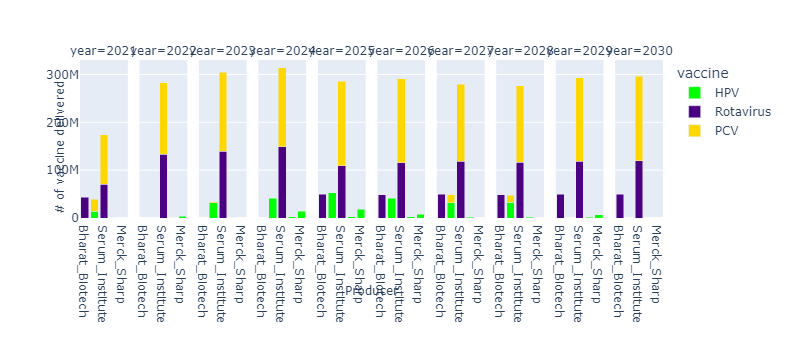

In [26]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go

with open('C:/Users/fthcn/Desktop/Vaccine_Tender_Scheduling_Problem/Julia_Files/Github/Results/X_results_'+demand_status+'_'+supply_status+'_'+price_status+'.json') as json_file:
    X_results = json.load(json_file)

print(X_results)

group = ["HPV", "Rotavirus", "PCV"]

output = pd.DataFrame()
for v in group:
    if v in X_results:
        #print(v)
        for p in P_v[v]:
            #print(p)
            for t in T:
                if str(t) in X_results[v][p]:
                    if X_results[v][p][str(t)] >= 1:
                        X_results[v][p][str(t)] = round(X_results[v][p][str(t)])
                        df_dictionary = pd.DataFrame([dict(year=str(2020+t), var=X_results[v][p][str(t)], vaccine=v, producer=p)])
                        output = pd.concat([output, df_dictionary], ignore_index=True)
output.sort_values(['year'],ascending=[True],inplace=True)
fig = px.bar(output, x="producer", y="var", facet_col="year", color="vaccine", color_discrete_map=vaccine_color_map)

fig.for_each_xaxis(lambda x: x.update(title = ''))
fig.for_each_yaxis(lambda y: y.update(title = ''))
# and:
fig.add_annotation(x=-0.05,y=0.45, showarrow=False,
                   text="# of vaccine delivered", textangle=-90,
                    xref="paper", yref="paper")
fig.add_annotation(x=0.5,y=-0.52, showarrow=False,
                   text="Producer", textangle=0,
                    xref="paper", yref="paper")
fig.update_layout(barmode='stack', xaxis={'categoryorder':'category ascending'})
fig.show()

{'PCV': {}, 'Measles': {}, 'IPV': {}, 'Mumps': {}, 'HPV': {'2': 10720000.0, '10': 47280000.0, '9': 19280000.0}, 'Hib': {}, 'Pertussis': {}, 'Rotavirus': {}, 'Diphtheria': {}, 'Hepatitis_B': {}, 'Tetanus': {}, 'Rubella': {}}
{'PCV': {'5': 176800000.0, '4': 164720000.0, '6': 175280000.0, '7': 177840000.0, '2': 149600000.0, '10': 176160000.0, '9': 175040000.0, '8': 173840000.0, '3': 167360000.0, '1': 128640000.0}, 'Measles': {'5': 250960000.0, '4': 238560000.0, '6': 326000000.0, '7': 223200000.0, '2': 233600000.0, '10': 279040000.0, '9': 249200000.0, '8': 325200000.0, '3': 257760000.0, '1': 297680000.0}, 'IPV': {'5': 473360000.0, '4': 472560000.0, '6': 458000000.0, '7': 104640000.0, '2': 465760000.0, '10': 106400000.0, '9': 104640000.0, '8': 102800000.0, '3': 486880000.0, '1': 417760000.0}, 'Mumps': {'5': 18800000.0, '4': 20240000.0, '6': 12960000.0, '7': 14960000.0, '2': 21280000.0, '10': 10400000.0, '9': 8560000.0, '8': 7120000.0, '3': 20640000.0, '1': 20880000.0}, 'HPV': {'5': 74160000

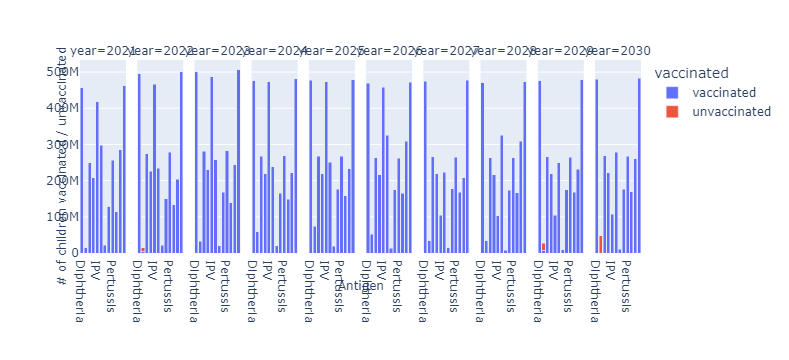

In [27]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go

with open('C:/Users/fthcn/Desktop/Vaccine_Tender_Scheduling_Problem/Julia_Files/Github/Results/S_results_'+demand_status+'_'+supply_status+'_'+price_status+'.json') as json_file:
    S_results = json.load(json_file)

with open('C:/Users/fthcn/Desktop/Vaccine_Tender_Scheduling_Problem/Julia_Files/Github/Results/Vc_antigen_results_'+demand_status+'_'+supply_status+'_'+price_status+'.json') as json_file:
    Vc_results = json.load(json_file)

print(S_results)
print(Vc_results)

group = ["Measles", "Mumps", "Rubella", "Diphtheria", "Tetanus", "Pertussis", "Hepatitis_B", "Hib", "IPV", "HPV", "Rotavirus", "PCV"]

output = pd.DataFrame()
for a in group:
    for t in T:
        if str(t) in Vc_results[a]:
            if Vc_results[a][str(t)] >= 1:
                Vc_results[a][str(t)] = round(Vc_results[a][str(t)])
                df_dictionary = pd.DataFrame([dict(year=str(2020+t), var=Vc_results[a][str(t)], antigen=a, vaccinated="vaccinated")])
                output = pd.concat([output, df_dictionary], ignore_index=True)
        if str(t) in S_results[a]:
            if S_results[a][str(t)] >= 1:
                S_results[a][str(t)] = round(S_results[a][str(t)])
                df_dictionary = pd.DataFrame([dict(year=str(2020+t), var=S_results[a][str(t)], antigen=a, vaccinated="unvaccinated")])
                output = pd.concat([output, df_dictionary], ignore_index=True)

# following two lines are used to generate index "unvaccinated" when there is no value for S variable
df_dictionary = pd.DataFrame([dict(year=str(2021), var=0, antigen=a, vaccinated="unvaccinated")])
output = pd.concat([output, df_dictionary], ignore_index=True)
output.sort_values(['year'],ascending=[True],inplace=True)
fig = px.bar(output, x="antigen", y="var", facet_col="year", color="vaccinated")

fig.for_each_xaxis(lambda x: x.update(title = ''))
fig.for_each_yaxis(lambda y: y.update(title = ''))
# and:
fig.add_annotation(x=-0.05,y=0.45, showarrow=False,
                   text="# of children vaccinated / unvaccinated", textangle=-90,
                    xref="paper", yref="paper")
fig.add_annotation(x=0.5,y=-0.22, showarrow=False,
                   text="Antigen", textangle=0,
                    xref="paper", yref="paper")

fig.update_layout(barmode='stack', xaxis={'categoryorder':'category ascending'})

{'PCV': {}, 'DTwP-Hib': {}, 'IPV': {}, 'Hexa': {}, 'HPV': {}, 'Hib': {}, 'M': {}, 'DT': {}, 'HepB': {}, 'MMR': {}, 'Td': {}, 'Rotavirus': {}, 'TT': {}, 'MR': {}, 'Penta': {}, 'DTwP': {}, 'OPV': {}}


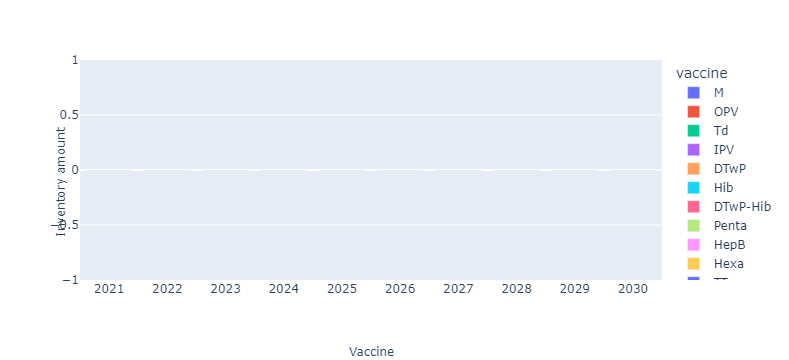

In [29]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go

with open('C:/Users/fthcn/Desktop/Vaccine_Tender_Scheduling_Problem/Julia_Files/Github/Results/I_results_'+demand_status+'_'+supply_status+'_'+price_status+'.json') as json_file:
    I_results = json.load(json_file)

print(I_results)

group = ["M", "MR", "MMR", "TT", "HepB", "Hib", "IPV", "OPV", "DT", "Td", "DTwP", "DTwP-Hib", "Penta", "Hexa", "HPV", "Rotavirus", "PCV"]

output = pd.DataFrame()
for v in group:
    for t in T:
        if str(t) in I_results[v]:
            if I_results[v][str(t)] >= 1:
                I_results[v][str(t)] = round(I_results[v][str(t)])
                df_dictionary = pd.DataFrame([dict(year=str(2020+t), var=I_results[v][str(t)], vaccine=v)])
                output = pd.concat([output, df_dictionary], ignore_index=True)
        else:
            df_dictionary = pd.DataFrame([dict(year=str(2020+t), var=0, vaccine=v)])
            output = pd.concat([output, df_dictionary], ignore_index=True)
output.sort_values(['year'],ascending=[True],inplace=True)
fig = px.bar(output, x="year", y="var", color="vaccine")

#fig = px.bar(long_df, x="nation", y="count", color="medal", title="Long-Form Input")

fig.for_each_xaxis(lambda x: x.update(title = ''))
fig.for_each_yaxis(lambda y: y.update(title = ''))
# and:
fig.add_annotation(x=-0.05,y=0.45, showarrow=False,
                   text="Inventory amount", textangle=-90,
                    xref="paper", yref="paper")
fig.add_annotation(x=0.5,y=-0.37, showarrow=False,
                   text="Vaccine", textangle=0,
                    xref="paper", yref="paper")

fig.update_layout(barmode='stack', xaxis={'categoryorder':'category ascending'})

{'PCV': {}, 'Measles': {}, 'IPV': {}, 'Mumps': {}, 'HPV': {}, 'Hib': {}, 'Pertussis': {}, 'Rotavirus': {}, 'Diphtheria': {}, 'Hepatitis_B': {}, 'Tetanus': {}, 'Rubella': {}}
{'PCV': {'5': 176800000.0, '4': 164720000.0, '6': 175280000.0, '7': 177840000.0, '2': 149600000.0, '10': 176160000.0, '9': 175040000.0, '8': 173840000.0, '3': 167360000.0, '1': 128640000.0}, 'Measles': {'5': 250960000.0, '4': 238560000.0, '6': 326000000.0, '7': 223200000.0, '2': 233600000.0, '10': 279040000.0, '9': 249200000.0, '8': 325200000.0, '3': 257760000.0, '1': 297680000.0}, 'IPV': {'5': 473360000.0, '4': 472560000.0, '6': 458000000.0, '7': 104640000.0, '2': 465760000.0, '10': 106400000.00000001, '9': 104640000.0, '8': 102800000.0, '3': 486880000.0, '1': 417760000.0}, 'Mumps': {'5': 18800000.0, '4': 20240000.0, '6': 12960000.0, '7': 14960000.0, '2': 21280000.0, '10': 10400000.0, '9': 8560000.0, '8': 7120000.0, '3': 20640000.0, '1': 20880000.0}, 'HPV': {'5': 74160000.0, '4': 58240000.0, '6': 51760000.0, '7': 

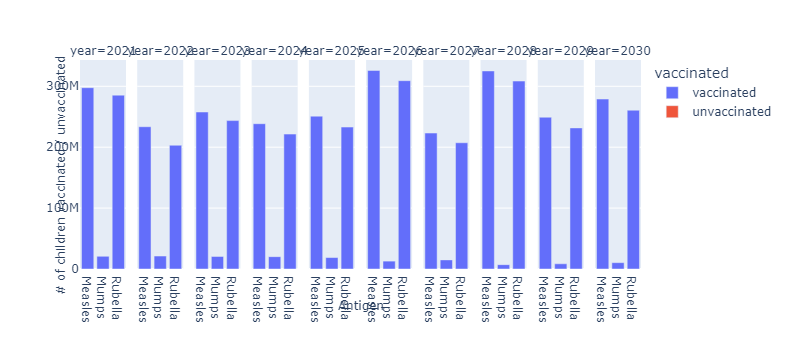

In [157]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go

with open('C:/Users/fthcn/Desktop/Vaccine_Tender_Scheduling_Problem/Julia_Files/Github/Results/S_results_'+demand_status+'_'+supply_status+'_'+price_status+'.json') as json_file:
    S_results = json.load(json_file)

with open('C:/Users/fthcn/Desktop/Vaccine_Tender_Scheduling_Problem/Julia_Files/Github/Results/Vc_antigen_results_'+demand_status+'_'+supply_status+'_'+price_status+'.json') as json_file:
    Vc_results = json.load(json_file)

print(S_results)
print(Vc_results)

group = ["Measles","Mumps","Rubella"]

output = pd.DataFrame()
for a in group:
    for t in T:
        if str(t) in Vc_results[a]:
            if Vc_results[a][str(t)] >= 1:
                Vc_results[a][str(t)] = round(Vc_results[a][str(t)])
                df_dictionary = pd.DataFrame([dict(year=str(2020+t), var=Vc_results[a][str(t)], antigen=a, vaccinated="vaccinated")])
                output = pd.concat([output, df_dictionary], ignore_index=True)
        if str(t) in S_results[a]:
            if S_results[a][str(t)] >= 1:
                S_results[a][str(t)] = round(S_results[a][str(t)])
                df_dictionary = pd.DataFrame([dict(year=str(2020+t), var=S_results[a][str(t)], antigen=a, vaccinated="unvaccinated")])
                output = pd.concat([output, df_dictionary], ignore_index=True)

# following two lines are used to generate index "unvaccinated" when there is no value for S variable
df_dictionary = pd.DataFrame([dict(year=str(2021), var=0, antigen=a, vaccinated="unvaccinated")])
output = pd.concat([output, df_dictionary], ignore_index=True)

fig = px.bar(output, x="antigen", y="var", facet_col="year", color="vaccinated")

fig.for_each_xaxis(lambda x: x.update(title = ''))
fig.for_each_yaxis(lambda y: y.update(title = ''))
# and:
fig.add_annotation(x=-0.05,y=0.45, showarrow=False,
                   text="# of children vaccinated / unvaccinated", textangle=-90,
                    xref="paper", yref="paper")
fig.add_annotation(x=0.5,y=-0.22, showarrow=False,
                   text="Antigen", textangle=0,
                    xref="paper", yref="paper")

{'PCV': {}, 'Measles': {}, 'IPV': {}, 'Mumps': {}, 'HPV': {}, 'Hib': {}, 'Pertussis': {}, 'Rotavirus': {}, 'Diphtheria': {}, 'Hepatitis_B': {}, 'Tetanus': {}, 'Rubella': {}}
{'PCV': {'5': 176800000.0, '4': 164720000.0, '6': 175280000.0, '7': 177840000.0, '2': 149600000.0, '10': 176160000.0, '9': 175040000.0, '8': 173840000.0, '3': 167360000.0, '1': 128640000.0}, 'Measles': {'5': 250960000.0, '4': 238560000.0, '6': 326000000.0, '7': 223200000.0, '2': 233600000.0, '10': 279040000.0, '9': 249200000.0, '8': 325200000.0, '3': 257760000.0, '1': 297680000.0}, 'IPV': {'5': 473360000.0, '4': 472560000.0, '6': 458000000.0, '7': 104640000.0, '2': 465760000.0, '10': 106400000.00000001, '9': 104640000.0, '8': 102800000.0, '3': 486880000.0, '1': 417760000.0}, 'Mumps': {'5': 18800000.0, '4': 20240000.0, '6': 12960000.0, '7': 14960000.0, '2': 21280000.0, '10': 10400000.0, '9': 8560000.0, '8': 7120000.0, '3': 20640000.0, '1': 20880000.0}, 'HPV': {'5': 74160000.0, '4': 58240000.0, '6': 51760000.0, '7': 

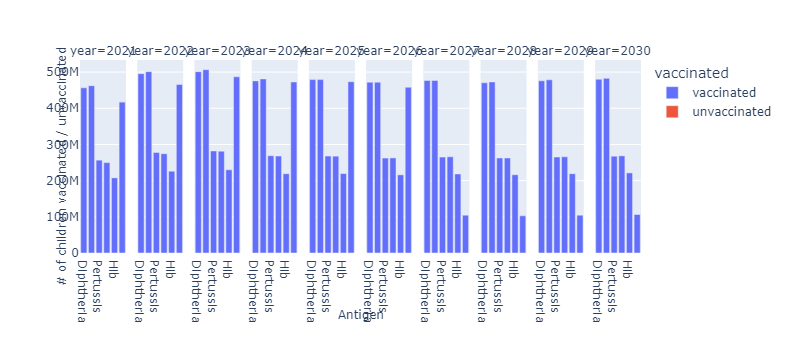

In [158]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go

with open('C:/Users/fthcn/Desktop/Vaccine_Tender_Scheduling_Problem/Julia_Files/Github/Results/S_results_'+demand_status+'_'+supply_status+'_'+price_status+'.json') as json_file:
    S_results = json.load(json_file)

with open('C:/Users/fthcn/Desktop/Vaccine_Tender_Scheduling_Problem/Julia_Files/Github/Results/Vc_antigen_results_'+demand_status+'_'+supply_status+'_'+price_status+'.json') as json_file:
    Vc_results = json.load(json_file)

print(S_results)
print(Vc_results)

group = ["Diphtheria","Tetanus","Pertussis","Hepatitis_B","Hib","IPV"]

output = pd.DataFrame()
for a in group:
    for t in T:
        if str(t) in Vc_results[a]:
            if Vc_results[a][str(t)] >= 1:
                Vc_results[a][str(t)] = round(Vc_results[a][str(t)])
                df_dictionary = pd.DataFrame([dict(year=str(2020+t), var=Vc_results[a][str(t)], antigen=a, vaccinated="vaccinated")])
                output = pd.concat([output, df_dictionary], ignore_index=True)
        if str(t) in S_results[a]:
            if S_results[a][str(t)] >= 1:
                S_results[a][str(t)] = round(S_results[a][str(t)])
                df_dictionary = pd.DataFrame([dict(year=str(2020+t), var=S_results[a][str(t)], antigen=a, vaccinated="unvaccinated")])
                output = pd.concat([output, df_dictionary], ignore_index=True)

# following two lines are used to generate index "unvaccinated" when there is no value for S variable
df_dictionary = pd.DataFrame([dict(year=str(2021), var=0, antigen=a, vaccinated="unvaccinated")])
output = pd.concat([output, df_dictionary], ignore_index=True)

fig = px.bar(output, x="antigen", y="var", facet_col="year", color="vaccinated")

fig.for_each_xaxis(lambda x: x.update(title = ''))
fig.for_each_yaxis(lambda y: y.update(title = ''))
# and:
fig.add_annotation(x=-0.05,y=0.45, showarrow=False,
                   text="# of children vaccinated / unvaccinated", textangle=-90,
                    xref="paper", yref="paper")
fig.add_annotation(x=0.5,y=-0.37, showarrow=False,
                   text="Antigen", textangle=0,
                    xref="paper", yref="paper")

{'PCV': {}, 'Measles': {}, 'IPV': {}, 'Mumps': {}, 'HPV': {}, 'Hib': {}, 'Pertussis': {}, 'Rotavirus': {}, 'Diphtheria': {}, 'Hepatitis_B': {}, 'Tetanus': {}, 'Rubella': {}}
{'PCV': {'5': 176800000.0, '4': 164720000.0, '6': 175280000.0, '7': 177840000.0, '2': 149600000.0, '10': 176160000.0, '9': 175040000.0, '8': 173840000.0, '3': 167360000.0, '1': 128640000.0}, 'Measles': {'5': 250960000.0, '4': 238560000.0, '6': 326000000.0, '7': 223200000.0, '2': 233600000.0, '10': 279040000.0, '9': 249200000.0, '8': 325200000.0, '3': 257760000.0, '1': 297680000.0}, 'IPV': {'5': 473360000.0, '4': 472560000.0, '6': 458000000.0, '7': 104640000.0, '2': 465760000.0, '10': 106400000.00000001, '9': 104640000.0, '8': 102800000.0, '3': 486880000.0, '1': 417760000.0}, 'Mumps': {'5': 18800000.0, '4': 20240000.0, '6': 12960000.0, '7': 14960000.0, '2': 21280000.0, '10': 10400000.0, '9': 8560000.0, '8': 7120000.0, '3': 20640000.0, '1': 20880000.0}, 'HPV': {'5': 74160000.0, '4': 58240000.0, '6': 51760000.0, '7': 

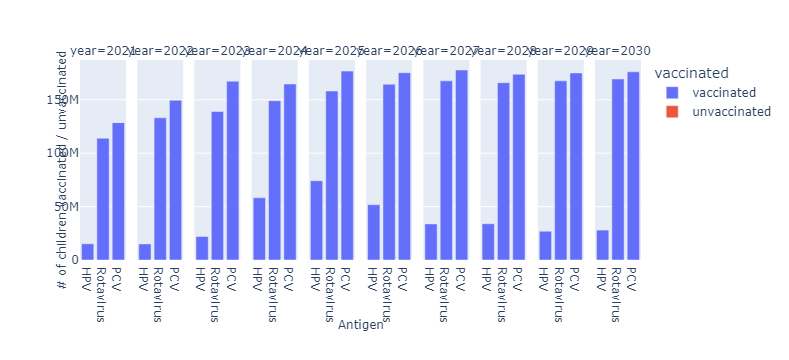

In [159]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go

with open('C:/Users/fthcn/Desktop/Vaccine_Tender_Scheduling_Problem/Julia_Files/Github/Results/S_results_'+demand_status+'_'+supply_status+'_'+price_status+'.json') as json_file:
    S_results = json.load(json_file)

with open('C:/Users/fthcn/Desktop/Vaccine_Tender_Scheduling_Problem/Julia_Files/Github/Results/Vc_antigen_results_'+demand_status+'_'+supply_status+'_'+price_status+'.json') as json_file:
    Vc_results = json.load(json_file)

print(S_results)
print(Vc_results)

group = ["HPV", "Rotavirus", "PCV"]

output = pd.DataFrame()
for a in group:
    for t in T:
        if str(t) in Vc_results[a]:
            if Vc_results[a][str(t)] >= 1:
                Vc_results[a][str(t)] = round(Vc_results[a][str(t)])
                df_dictionary = pd.DataFrame([dict(year=str(2020+t), var=Vc_results[a][str(t)], antigen=a, vaccinated="vaccinated")])
                output = pd.concat([output, df_dictionary], ignore_index=True)
        if str(t) in S_results[a]:
            if S_results[a][str(t)] >= 1:
                S_results[a][str(t)] = round(S_results[a][str(t)])
                df_dictionary = pd.DataFrame([dict(year=str(2020+t), var=S_results[a][str(t)], antigen=a, vaccinated="unvaccinated")])
                output = pd.concat([output, df_dictionary], ignore_index=True)

# following two lines are used to generate index "unvaccinated" when there is no value for S variable
df_dictionary = pd.DataFrame([dict(year=str(2021), var=0, antigen=a, vaccinated="unvaccinated")])
output = pd.concat([output, df_dictionary], ignore_index=True)

fig = px.bar(output, x="antigen", y="var", facet_col="year", color="vaccinated")

fig.for_each_xaxis(lambda x: x.update(title = ''))
fig.for_each_yaxis(lambda y: y.update(title = ''))
# and:
fig.add_annotation(x=-0.05,y=0.45, showarrow=False,
                   text="# of children vaccinated / unvaccinated", textangle=-90,
                    xref="paper", yref="paper")
fig.add_annotation(x=0.5,y=-0.37, showarrow=False,
                   text="Antigen", textangle=0,
                    xref="paper", yref="paper")

{'PCV': {}, 'DTwP-Hib': {}, 'IPV': {}, 'Hexa': {}, 'HPV': {}, 'Hib': {}, 'M': {}, 'DT': {}, 'HepB': {}, 'MMR': {}, 'Td': {}, 'Rotavirus': {}, 'TT': {'9': 2400000.0}, 'MR': {}, 'Penta': {}, 'DTwP': {}, 'OPV': {}}


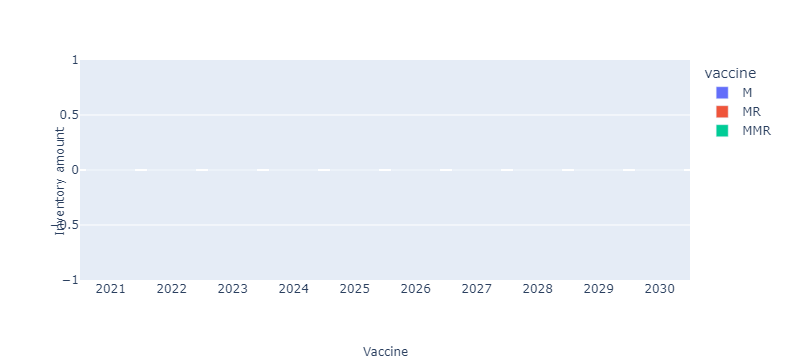

In [160]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go

with open('C:/Users/fthcn/Desktop/Vaccine_Tender_Scheduling_Problem/Julia_Files/Github/Results/I_results_'+demand_status+'_'+supply_status+'_'+price_status+'.json') as json_file:
    I_results = json.load(json_file)

print(I_results)

group = ["M","MR","MMR"]

output = pd.DataFrame()
for v in group:
    for t in T:
        if str(t) in I_results[v]:
            if I_results[v][str(t)] >= 1:
                I_results[v][str(t)] = round(I_results[v][str(t)])
                df_dictionary = pd.DataFrame([dict(year=str(2020+t), var=I_results[v][str(t)], vaccine=v)])
                output = pd.concat([output, df_dictionary], ignore_index=True)
        else:
            df_dictionary = pd.DataFrame([dict(year=str(2020+t), var=0, vaccine=v)])
            output = pd.concat([output, df_dictionary], ignore_index=True)

fig = px.bar(output, x="year", y="var", color="vaccine")

#fig = px.bar(long_df, x="nation", y="count", color="medal", title="Long-Form Input")

fig.for_each_xaxis(lambda x: x.update(title = ''))
fig.for_each_yaxis(lambda y: y.update(title = ''))
# and:
fig.add_annotation(x=-0.05,y=0.45, showarrow=False,
                   text="Inventory amount", textangle=-90,
                    xref="paper", yref="paper")
fig.add_annotation(x=0.5,y=-0.37, showarrow=False,
                   text="Vaccine", textangle=0,
                    xref="paper", yref="paper")

{'PCV': {}, 'DTwP-Hib': {}, 'IPV': {}, 'Hexa': {}, 'HPV': {}, 'Hib': {}, 'M': {}, 'DT': {}, 'HepB': {}, 'MMR': {}, 'Td': {}, 'Rotavirus': {}, 'TT': {'9': 2400000.0}, 'MR': {}, 'Penta': {}, 'DTwP': {}, 'OPV': {}}


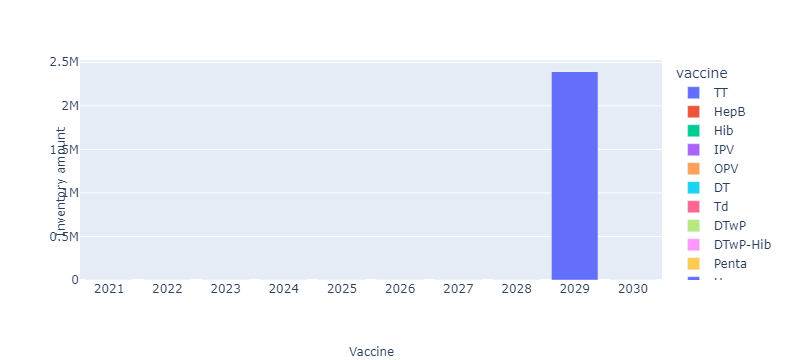

In [161]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go

with open('C:/Users/fthcn/Desktop/Vaccine_Tender_Scheduling_Problem/Julia_Files/Github/Results/I_results_'+demand_status+'_'+supply_status+'_'+price_status+'.json') as json_file:
    I_results = json.load(json_file)

print(I_results)

group = ["TT", "HepB", "Hib", "IPV", "OPV", "DT", "Td", "DTwP", "DTwP-Hib", "Penta", "Hexa"]

output = pd.DataFrame()
for v in group:
    for t in T:
        if str(t) in I_results[v]:
            if I_results[v][str(t)] >= 1:
                I_results[v][str(t)] = round(I_results[v][str(t)])
                df_dictionary = pd.DataFrame([dict(year=str(2020+t), var=I_results[v][str(t)], vaccine=v)])
                output = pd.concat([output, df_dictionary], ignore_index=True)
        else:
            df_dictionary = pd.DataFrame([dict(year=str(2020+t), var=0, vaccine=v)])
            output = pd.concat([output, df_dictionary], ignore_index=True)

fig = px.bar(output, x="year", y="var", color="vaccine")

#fig = px.bar(long_df, x="nation", y="count", color="medal", title="Long-Form Input")

fig.for_each_xaxis(lambda x: x.update(title = ''))
fig.for_each_yaxis(lambda y: y.update(title = ''))
# and:
fig.add_annotation(x=-0.05,y=0.45, showarrow=False,
                   text="Inventory amount", textangle=-90,
                    xref="paper", yref="paper")
fig.add_annotation(x=0.5,y=-0.37, showarrow=False,
                   text="Vaccine", textangle=0,
                    xref="paper", yref="paper")

{'PCV': {}, 'DTwP-Hib': {}, 'IPV': {}, 'Hexa': {}, 'HPV': {}, 'Hib': {}, 'M': {}, 'DT': {}, 'HepB': {}, 'MMR': {}, 'Td': {}, 'Rotavirus': {}, 'TT': {'9': 2400000.0}, 'MR': {}, 'Penta': {}, 'DTwP': {}, 'OPV': {}}


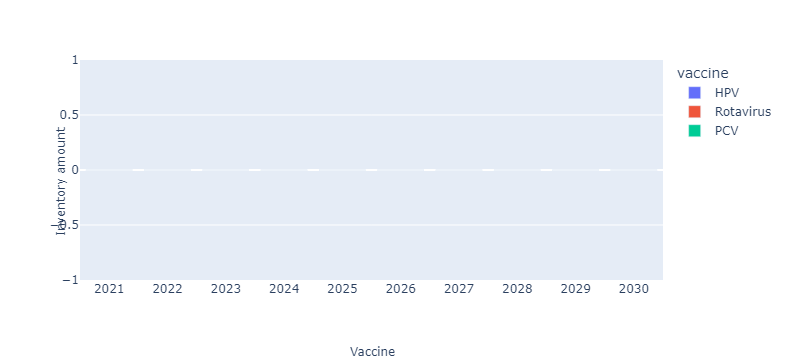

In [162]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go

with open('C:/Users/fthcn/Desktop/Vaccine_Tender_Scheduling_Problem/Julia_Files/Github/Results/I_results_'+demand_status+'_'+supply_status+'_'+price_status+'.json') as json_file:
    I_results = json.load(json_file)

print(I_results)

group = ["HPV", "Rotavirus", "PCV"]

output = pd.DataFrame()
for v in group:
    for t in T:
        if str(t) in I_results[v]:
            if I_results[v][str(t)] >= 1:
                I_results[v][str(t)] = round(I_results[v][str(t)])
                df_dictionary = pd.DataFrame([dict(year=str(2020+t), var=I_results[v][str(t)], vaccine=v)])
                output = pd.concat([output, df_dictionary], ignore_index=True)
        else:
            df_dictionary = pd.DataFrame([dict(year=str(2020+t), var=0, vaccine=v)])
            output = pd.concat([output, df_dictionary], ignore_index=True)

fig = px.bar(output, x="year", y="var", color="vaccine")

#fig = px.bar(long_df, x="nation", y="count", color="medal", title="Long-Form Input")

fig.for_each_xaxis(lambda x: x.update(title = ''))
fig.for_each_yaxis(lambda y: y.update(title = ''))
# and:
fig.add_annotation(x=-0.05,y=0.45, showarrow=False,
                   text="Inventory amount", textangle=-90,
                    xref="paper", yref="paper")
fig.add_annotation(x=0.5,y=-0.37, showarrow=False,
                   text="Vaccine", textangle=0,
                    xref="paper", yref="paper")